# 01: Image Preprocessing Exploration
Notebook này minh họa các bước tiền xử lý ảnh được sử dụng trong hệ thống Smart Parking, dựa trên code thực tế từ `backend/core_cv/preprocessing.py`.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Tách biệt hoàn toàn khỏi backend

def apply_preprocessing(image):
    # Kỹ thuật Chương 2: Tiền xử lý ảnh
    resized = cv2.resize(image, (64, 128))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(gray)
    blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
    return blurred


### 1. Tải ảnh mẫu
Chúng ta sẽ lấy một khung hình từ thư mục `data/raw_frames`.

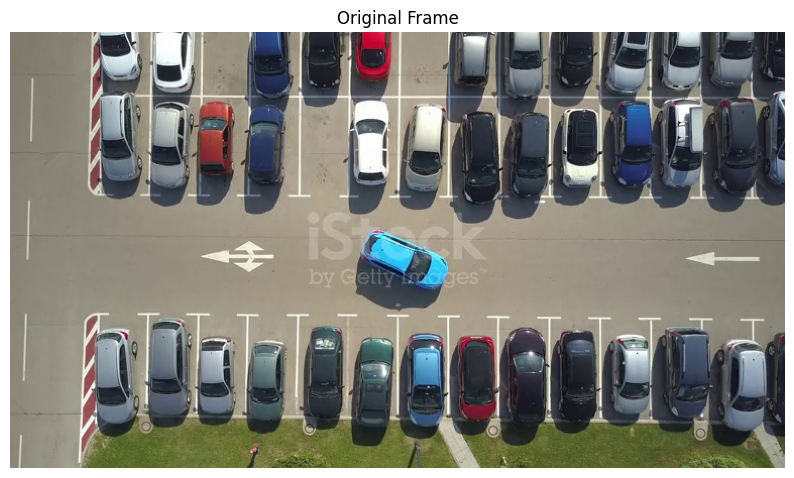

In [2]:
FRAME_PATH = '../data/raw_frames/frame_0000.jpg'
if os.path.exists(FRAME_PATH):
    img = cv2.imread(FRAME_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title("Original Frame")
    plt.axis('off')
    plt.show()
else:
    print("⚠️ Không tìm thấy ảnh mẫu. Vui lòng chạy backend/extract_frames.py trước!")

### 2. Các bước tiền xử lý chi tiết
Chúng ta sẽ tách nhỏ hàm `apply_preprocessing` để quan sát từng bước.

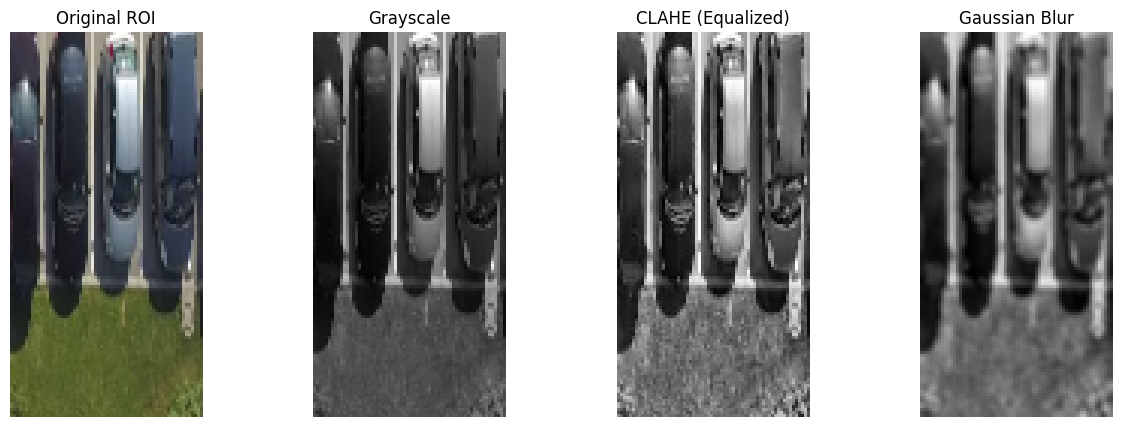

In [3]:
def explore_preprocessing(image):
    # 1. Resize
    resized = cv2.resize(image, (64, 128))
    
    # 2. Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    # 3. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(gray)
    
    # 4. Blur
    blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
    
    return resized, gray, equalized, blurred

if os.path.exists(FRAME_PATH):
    # Lấy một vùng nhỏ (ROI) giả định là một ô đỗ xe
    roi = img[300:500, 500:700]
    res, gray, equ, blu = explore_preprocessing(roi)
    
    titles = ['Original ROI', 'Grayscale', 'CLAHE (Equalized)', 'Gaussian Blur']
    images = [cv2.cvtColor(res, cv2.COLOR_BGR2RGB), gray, equ, blu]
    
    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(images[i], cmap='gray' if i > 0 else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

### 3. Phân tích Histogram
So sánh Histogram trước và sau khi áp dụng CLAHE để thấy sự khác biệt về độ tương phản.

C:\Users\haiau\AppData\Local\Temp\ipykernel_20428\2900723386.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(gray.ravel(), 256, [0, 256])
C:\Users\haiau\AppData\Local\Temp\ipykernel_20428\2900723386.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equ.ravel(), 256, [0, 256])


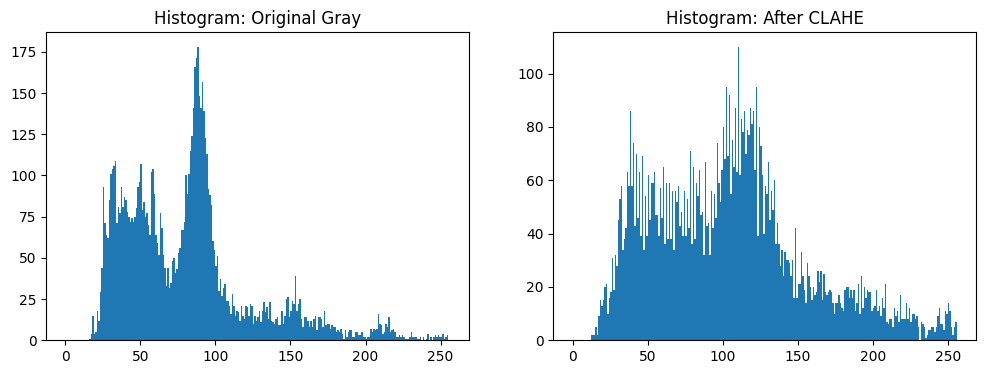

In [4]:
if os.path.exists(FRAME_PATH):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(gray.ravel(), 256, [0, 256])
    plt.title('Histogram: Original Gray')
    
    plt.subplot(1, 2, 2)
    plt.hist(equ.ravel(), 256, [0, 256])
    plt.title('Histogram: After CLAHE')
    
    plt.show()